In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Country-data.csv')

In [3]:
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
print(df.shape)

(167, 10)


In [5]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [7]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
display(df.describe())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

In [11]:
print(num_cols)
print(cat_cols)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
Index(['country'], dtype='object')


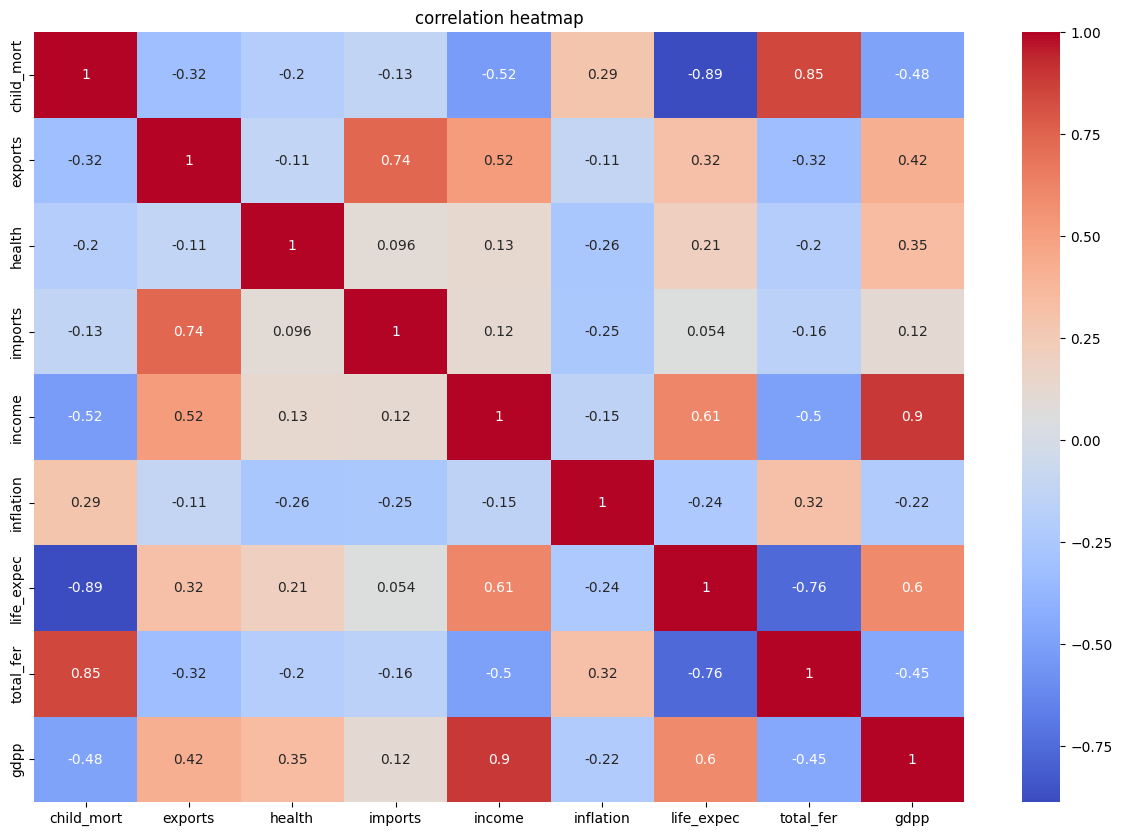

In [12]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,
            cmap='coolwarm'
            )
plt.title('correlation heatmap')
plt.show()

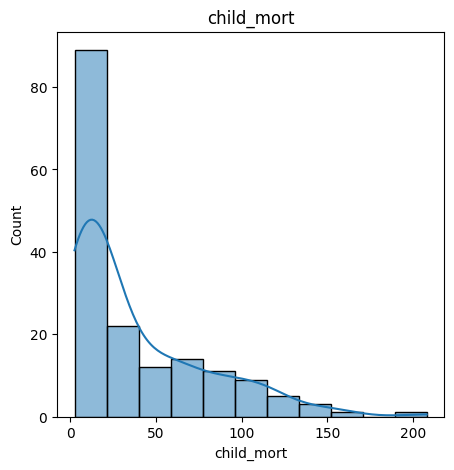

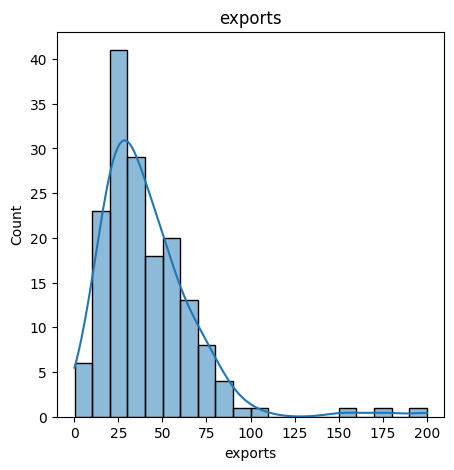

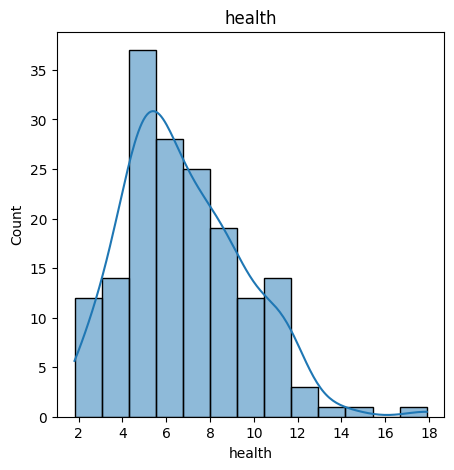

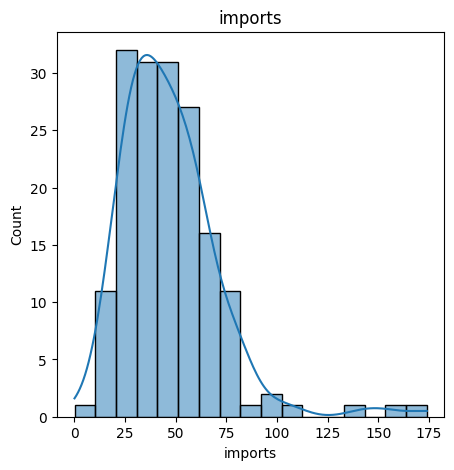

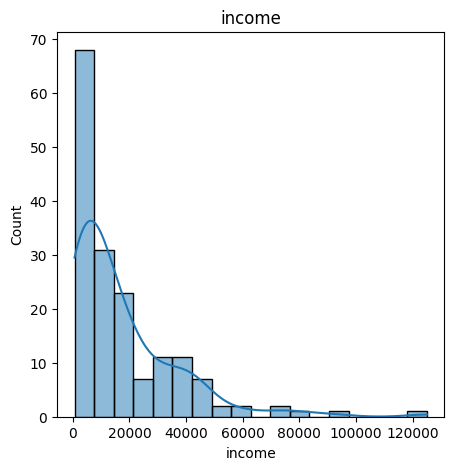

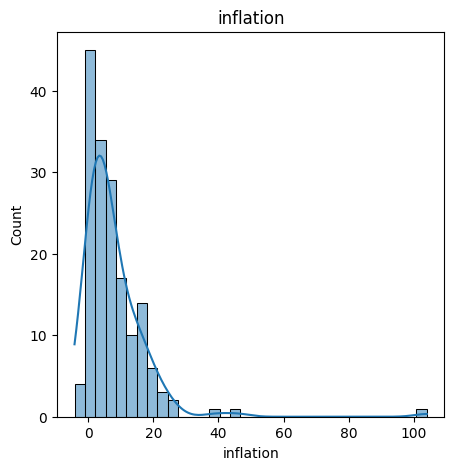

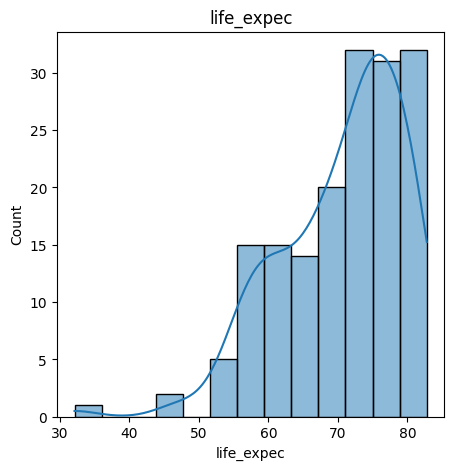

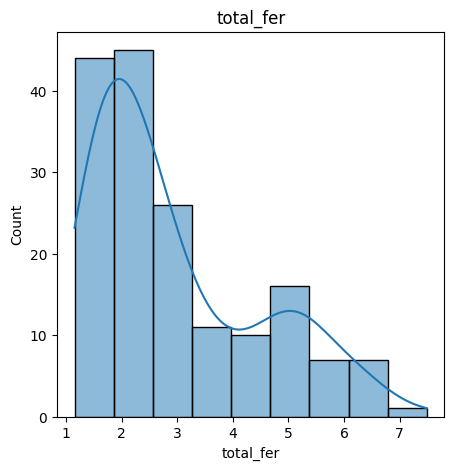

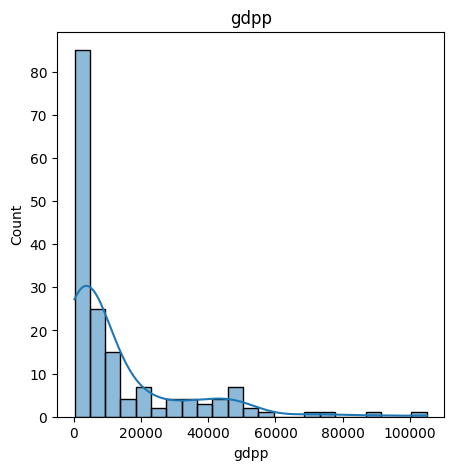

In [13]:
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

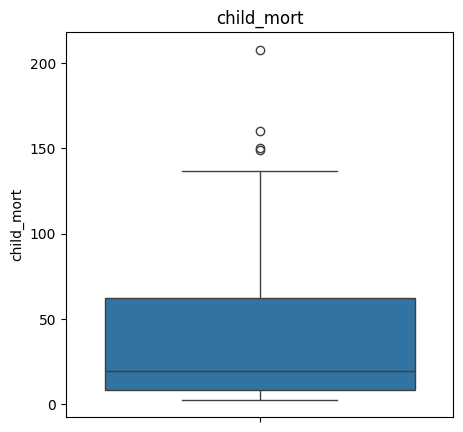

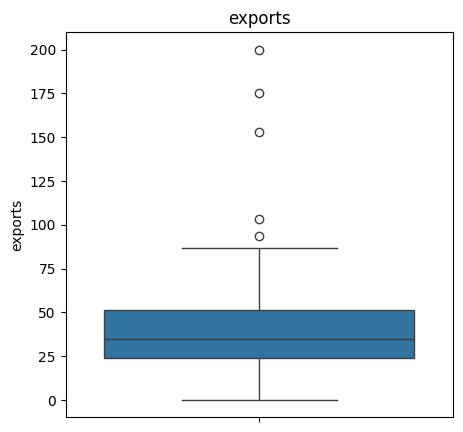

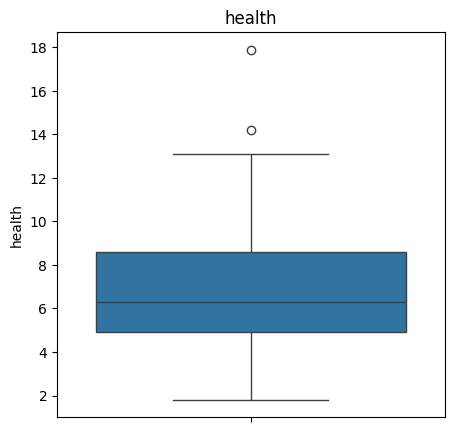

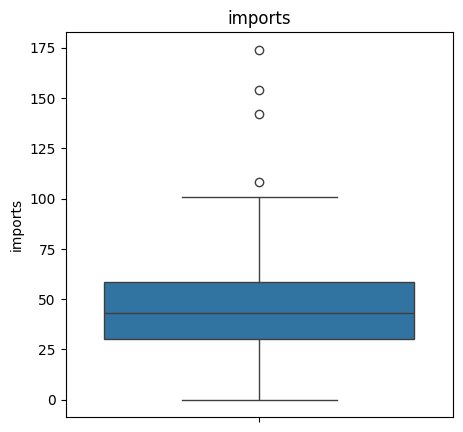

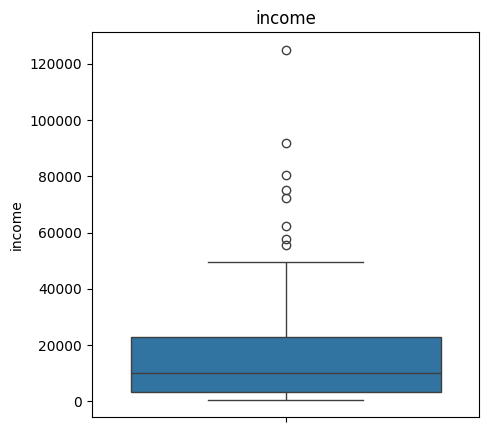

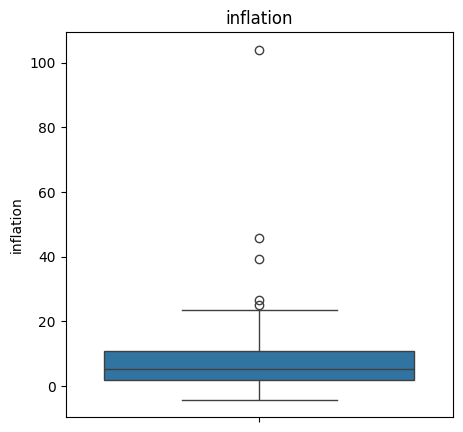

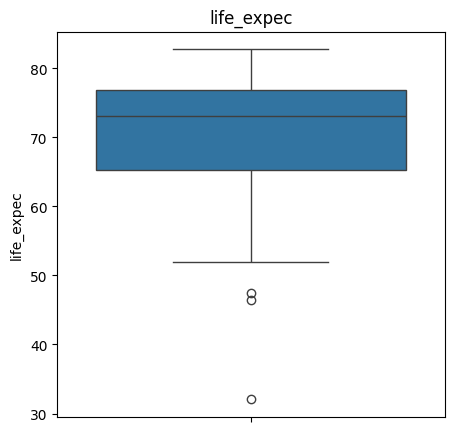

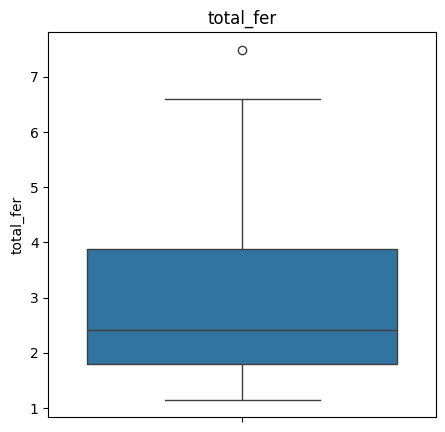

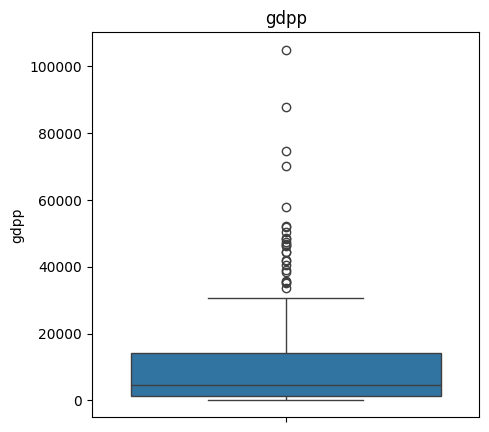

In [14]:
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [16]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Categorical Features:
Index(['country'], dtype='object')


In [17]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder()
    )
])

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [19]:
x_processed = preprocessor.fit_transform(df)

print(x_processed.shape)

(167, 176)


In [20]:
import joblib
joblib.dump(preprocessor,"preprocessing_pipeline.pkl")

['preprocessing_pipeline.pkl']

In [21]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

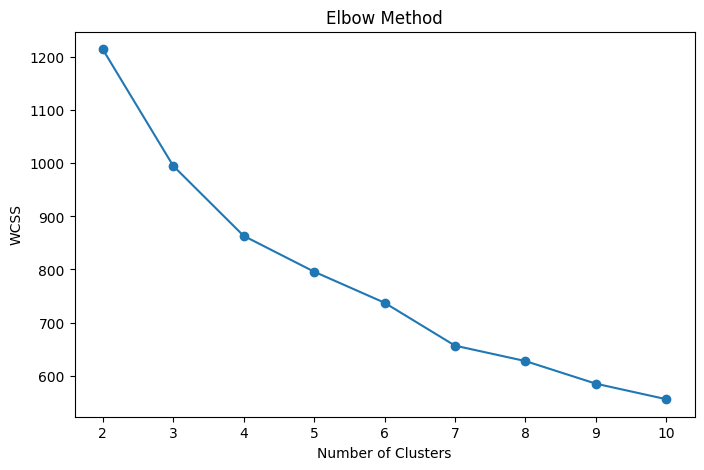

In [23]:
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_processed)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [26]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(x_processed)

    score = silhouette_score(
        x_processed,
        labels
    )

    print(f"K={k}  Silhouette={score:.3f}")

K=2  Silhouette=0.249
K=3  Silhouette=0.234
K=4  Silhouette=0.250
K=5  Silhouette=0.170
K=6  Silhouette=0.186
K=7  Silhouette=0.191
K=8  Silhouette=0.172
K=9  Silhouette=0.164
K=10  Silhouette=0.147


In [28]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(x_processed)

df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [29]:
print(df["Cluster"].value_counts())

Cluster
1    88
0    46
2    30
3     3
Name: count, dtype: int64


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_processed)

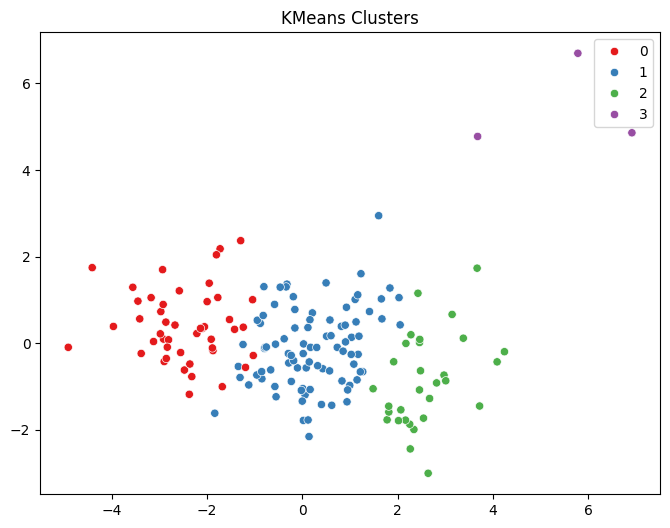

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set1"
)

plt.title("KMeans Clusters")

plt.show()

In [32]:
cluster_summary = df.groupby("Cluster").mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,93.841304,28.837174,6.346957,42.128261,3738.978261,12.087065,59.232609,5.054348,1826.130435
1,21.743182,41.316920,6.259318,48.075749,12972.386364,7.430580,72.755682,2.293295,6912.636364
2,4.953333,45.826667,9.168667,39.736667,45250.000000,2.742200,80.376667,1.795333,43333.333333
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


In [34]:
segment_names = {
    0: "Underdeveloped",
    1: "Developing",
    2: "Developed",
    3: "Advanced Economy"
}

df["Segment"] = df["Cluster"].map(segment_names)

df[["country", "Cluster", "Segment"]].head()

,country,Cluster,Segment
0,Afghanistan,0,Underdeveloped
1,Albania,1,Developing
2,Algeria,1,Developing
3,Angola,0,Underdeveloped
4,Antigua and Barbuda,1,Developing


In [36]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    x_processed
)

df["DBSCAN_Cluster"] = db_labels

print(
    df["DBSCAN_Cluster"]
    .value_counts()
)

DBSCAN_Cluster
-1    167
Name: count, dtype: int64


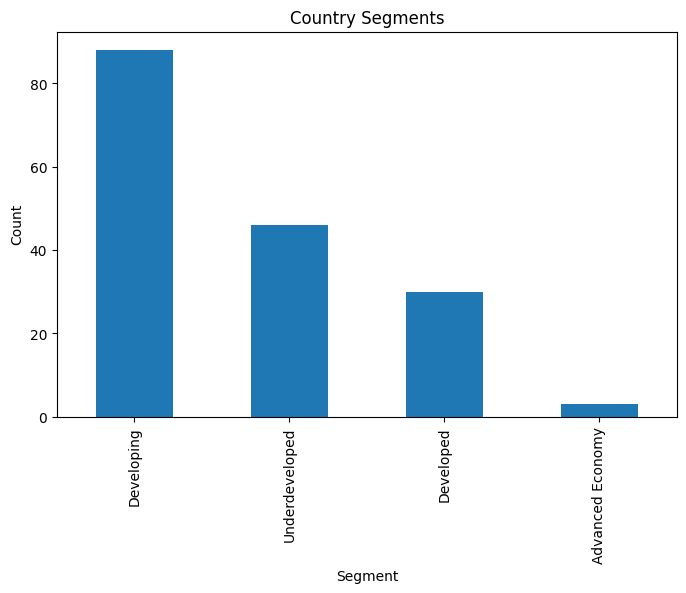

In [40]:
plt.figure(figsize=(8,5))

df["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Country Segments")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

In [41]:
df.to_csv(
    "country_segmented.csv",
    index=False
)

print("Segmented dataset saved.")

Segmented dataset saved.


In [83]:
x= df.drop(
    columns=["country","Cluster","Segment"]

)
y=df["Segment"]
print(x.shape)
print(y.shape)

(167, 10)
(167,)


In [84]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_features = x.columns

In [87]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [88]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features)
])

In [89]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [90]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print("Accuracy:", round(acc, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, preds))

    return acc

In [92]:
results = {}

results["Decision Tree"] = evaluate_model(
    dt_pipeline,
    x_train,
    x_test,
    y_train,
    y_test
)

Accuracy: 0.9706

Classification Report:

                  precision    recall  f1-score   support

Advanced Economy       1.00      1.00      1.00         1
       Developed       0.86      1.00      0.92         6
      Developing       1.00      0.94      0.97        18
  Underdeveloped       1.00      1.00      1.00         9

        accuracy                           0.97        34
       macro avg       0.96      0.99      0.97        34
    weighted avg       0.97      0.97      0.97        34



In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

results["Random Forest"] = evaluate_model(
    rf_pipeline,
    x_train,
    x_test,
    y_train,
    y_test
)

Accuracy: 0.9118

Classification Report:

                  precision    recall  f1-score   support

Advanced Economy       0.00      0.00      0.00         1
       Developed       0.75      1.00      0.86         6
      Developing       1.00      0.89      0.94        18
  Underdeveloped       0.90      1.00      0.95         9

        accuracy                           0.91        34
       macro avg       0.66      0.72      0.69        34
    weighted avg       0.90      0.91      0.90        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [94]:
from sklearn.ensemble import AdaBoostClassifier

ada_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ))
])

results["AdaBoost"] = evaluate_model(
    ada_pipeline,
    x_train,
    x_test,
    y_train,
    y_test
)

Accuracy: 0.9412

Classification Report:

                  precision    recall  f1-score   support

Advanced Economy       0.00      0.00      0.00         1
       Developed       0.75      1.00      0.86         6
      Developing       1.00      0.94      0.97        18
  Underdeveloped       1.00      1.00      1.00         9

        accuracy                           0.94        34
       macro avg       0.69      0.74      0.71        34
    weighted avg       0.93      0.94      0.93        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [95]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

results["Gradient Boosting"] = evaluate_model(
    gb_pipeline,
    x_train,
    x_test,
    y_train,
    y_test
)

Accuracy: 0.9706

Classification Report:

                  precision    recall  f1-score   support

Advanced Economy       1.00      1.00      1.00         1
       Developed       0.86      1.00      0.92         6
      Developing       1.00      0.94      0.97        18
  Underdeveloped       1.00      1.00      1.00         9

        accuracy                           0.97        34
       macro avg       0.96      0.99      0.97        34
    weighted avg       0.97      0.97      0.97        34



In [96]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [97]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=4,
        random_state=42
    ))
])

In [98]:
xgb_pipeline.fit(x_train, y_train_enc)

preds = xgb_pipeline.predict(x_test)

from sklearn.metrics import accuracy_score

results["XGBoost"] = accuracy_score(
    y_test_enc,
    preds
)

print("XGBoost Accuracy:",
      results["XGBoost"])

XGBoost Accuracy: 0.9411764705882353


In [99]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Decision Tree,0.970588
3,Gradient Boosting,0.970588
2,AdaBoost,0.941176
4,XGBoost,0.941176
1,Random Forest,0.911765


In [100]:
gb_pipeline.fit(x_train, y_train)

model = gb_pipeline.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

          Feature    Importance
8            gdpp  4.697305e-01
0      child_mort  4.261778e-01
7       total_fer  7.385957e-02
3         imports  1.063845e-02
4          income  5.178066e-03
1         exports  4.957334e-03
6      life_expec  4.882391e-03
2          health  4.575937e-03
5       inflation  2.956320e-12
9  DBSCAN_Cluster  0.000000e+00


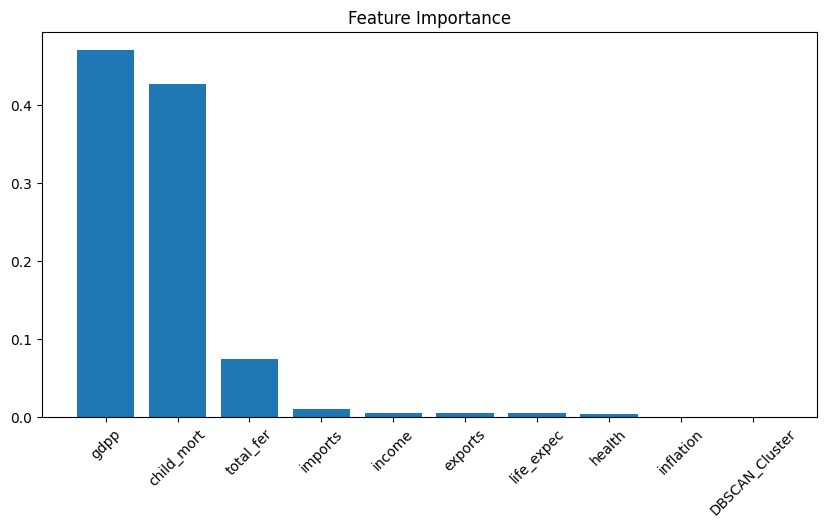

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [102]:
import joblib

joblib.dump(
    gb_pipeline,
    "customer_intelligence_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
